---
**Name : Aashoday S Surwade**\
**Roll No : 24AI126**\
**Class : SE-B AIML**\
**Course : FML**\
**FML Assignment 7**

---

**Problem Statement** :

Implement assignment based on K-Means clustering algorithm
and evaluate the performance,

*Case Study* : Anomaly Detection in Network Security:To detect
unusual or malicious activities (anomalies) in a computer
network by applying unsupervised learning (K-Means
Clustering). The algorithm will help separate normal traffic from
potential attacks or intrusions without relying on labeled data

---

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Load Data 
train = pd.read_csv("data/kdd_train.csv")
test = pd.read_csv("data/kdd_test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

df = pd.concat([train, test], axis=0).reset_index(drop=True)

print("Conbined Shape:", df.shape)

df.head()

Train Shape: (125973, 42)
Test Shape: (22544, 42)
Conbined Shape: (148517, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
# Separate labels and columns
y = df["labels"]
X = df.drop("labels", axis=1)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (148517, 41)
Label Shape: (148517,)


In [4]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
print("categorical columns:", categorical_cols)

categorical columns: Index(['protocol_type', 'service', 'flag'], dtype='object')


In [5]:
# Encode categorical features - One Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

X_encoded.head()

Shape before encoding: (148517, 41)
Shape after encoding: (148517, 122)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [6]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (148517, 122)


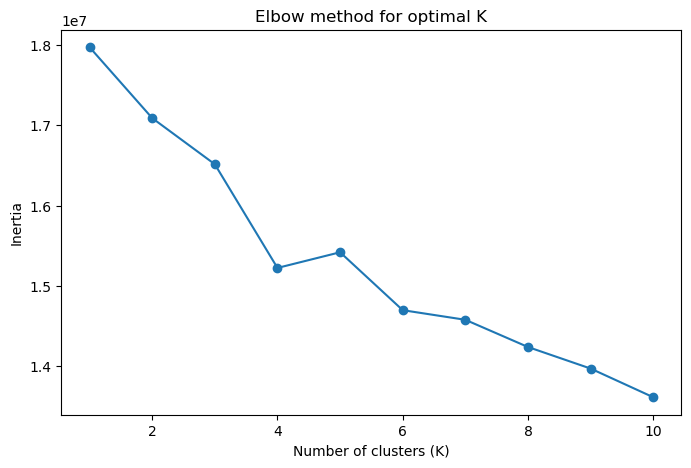

In [9]:
# Elbow method to find optimal k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow method for optimal K")
plt.show()

---
### Conclusion: 


---